In [25]:
import h5py
import numpy as np

def compare_hdf5_files(file1, file2, rtol=1e-8, atol=1e-12):
    """
    Compare two GIZMO HDF5 IC files robustly, checking shapes first.
    """
    f1 = h5py.File(file1, 'r')
    f2 = h5py.File(file2, 'r')

    def compare_groups(g1, g2, path="/"):
        for key in g1:
            if key not in g2:
                print(f"Missing key in second file: {path}{key}")
                continue
            item1 = g1[key]
            item2 = g2[key]

            if isinstance(item1, h5py.Group):
                compare_groups(item1, item2, path + key + "/")
            elif isinstance(item1, h5py.Dataset):
                d1 = item1[()]
                d2 = item2[()]
                if d1.shape != d2.shape:
                    print(f"Shape mismatch at {path}{key}: {d1.shape} vs {d2.shape}")
                    continue
                if not np.allclose(d1, d2, rtol=rtol, atol=atol):
                    print(f"Dataset differs at {path}{key}")
            else:
                print(f"Unknown item type at {path}{key}")

        # Compare attributes
        for attr in g1.attrs:
            if attr not in g2.attrs:
                print(f"Missing attribute in second file: {path}{attr}")
                continue
            v1 = g1.attrs[attr]
            v2 = g2.attrs[attr]
            if isinstance(v1, np.ndarray):
                if v1.shape != v2.shape:
                    print(f"Attribute shape mismatch at {path}{attr}: {v1.shape} vs {v2.shape}")
                    continue
                if not np.allclose(v1, v2, rtol=rtol, atol=atol):
                    print(f"Attribute differs at {path}{attr}")
            else:
                if v1 != v2:
                    print(f"Attribute differs at {path}{attr}")

    compare_groups(f1, f2)
    print("Comparison complete.")
    f1.close()
    f2.close()

def summarize_differences(file1, file2):
    with h5py.File(file1,'r') as f1, h5py.File(file2,'r') as f2:
        for key in f1['/PartType0']:
            d1 = f1['/PartType0'][key][()]
            d2 = f2['/PartType0'][key][()]
            # print(d1,d2) #particle id is different becuase i used array length instead of 1e8
            if d1.shape != d2.shape:
                print(f"{key}: shape {d1.shape} vs {d2.shape}")
            else:
                diff = d1 - d2
                if np.issubdtype(diff.dtype, np.floating):
                    print(f"{key}: max diff = {np.max(np.abs(diff))}, mean diff = {np.mean(np.abs(diff))}")
                else:
                    n_diff = np.sum(d1 != d2)
                    print(f"{key}: {n_diff} entries differ")

summarize_differences("n85_0.hdf5","n85.hdf5")

CompositionType: shape (1677709,) vs (1677714,)
Coordinates: shape (1677709, 3) vs (1677714, 3)
Entropy: shape (1677709,) vs (1677714,)
InternalEnergy: shape (1677709,) vs (1677714,)
Masses: shape (1677709,) vs (1677714,)
ParticleIDs: shape (1677709,) vs (1677714,)
Temperature: shape (1677709,) vs (1677714,)
Velocities: shape (1677709, 3) vs (1677714, 3)


2060964


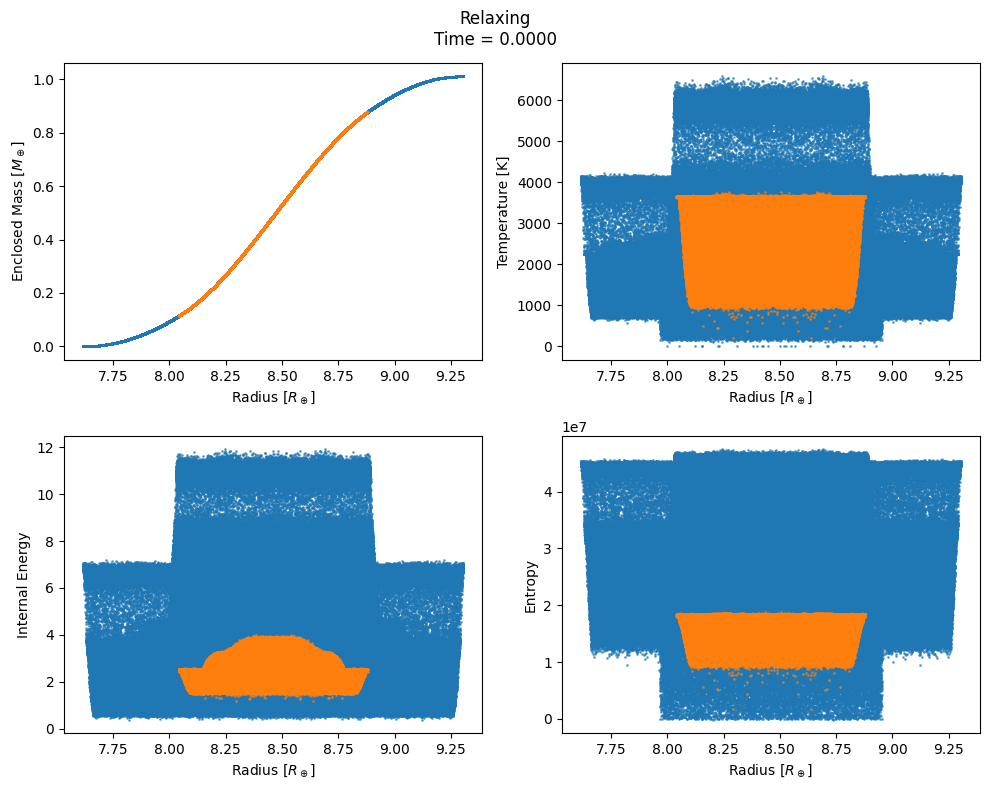

In [32]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

R_earth = 6.371e6
M_earth = 5.9724e24
mass_unit = 1/62.46  # GIZMO mass unit
gamma = 1.3          # approximate gamma for silicates/iron

fname = 'n50ic.hdf5'
# fname = f"{datadir}/snapshot_{i:03d}.hdf5"

with h5py.File(fname,'r') as f:
    pos = f['/PartType0/Coordinates'][()]   # code units
    m = f['/PartType0/Masses'][()]         # code units
    temp = f['/PartType0/Temperature'][()]
    compid = f['/PartType0/CompositionType'][()]

    entr = f['/PartType0/Entropy'][()]
    u = f['/PartType0/InternalEnergy'][()]
    time = f["Header"].attrs["Time"]
# Convert to physical units
r = np.linalg.norm(pos, axis=1)
m_phys = m * mass_unit    

# Sort by radius for cumulative mass
sort_idx = np.argsort(r)
r_sorted = r[sort_idx]
m_sorted = m_phys[sort_idx]

m_enc = np.cumsum(m_sorted)
unique_comp = np.unique(compid)

# -------- plotting --------
fig, ax = plt.subplots(2, 2, figsize=(10,8))
fig.suptitle(f"Relaxing\nTime = {time:.4f}")

# --- (1) enclosed mass ---
for compi in unique_comp:
    mask = compid[sort_idx] == compi
    ax[0,0].plot(r_sorted[mask], m_enc[mask], '.', ms=1)
ax[0,0].set_xlabel(r"Radius [$R_\oplus]$")
ax[0,0].set_ylabel(r"Enclosed Mass $[M_\oplus]$")

# --- (2) temperature ---
for compi in unique_comp:
    mask = compid == compi
    ax[0,1].scatter(r[mask], temp[mask], s=1, alpha=0.6)

ax[0,1].set_xlabel(r"Radius [$R_\oplus]$")
ax[0,1].set_ylabel("Temperature [K]")

# --- (3) internal energy ---
for compi in unique_comp:
    mask = compid == compi
    ax[1,0].scatter(r[mask], u[mask], s=1, alpha=0.6)

ax[1,0].set_xlabel(r"Radius [$R_\oplus]$")
ax[1,0].set_ylabel("Internal Energy")

# --- (4) entropy ---
for compi in unique_comp:
    mask = compid == compi
    ax[1,1].scatter(r[mask], entr[mask], s=1, alpha=0.6)

ax[1,1].set_xlabel(r"Radius [$R_\oplus]$")
ax[1,1].set_ylabel("Entropy")

# --- limits ---
# for a in ax.flat:
#     a.set_xlim(0, 1.1)

# ax[0,0].set_ylim(0, 0.9)
# ax[0,1].set_ylim(500, 5000)

# # log scale helps a LOT
# ax[1,0].set_yscale('log')
# # ax[1,1].set_yscale('log')

plt.tight_layout()

print(len(pos))

In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

R_earth = 6.371e6
M_earth = 5.9724e24
mass_unit = 1/62.46  # GIZMO mass unit
gamma = 1.3          # approximate gamma for silicates/iron

snap_start = 0
snap_end   = 300

massratio = 0.5           #planet mass/Earth mass
datadir = f"data{massratio*100:.0f}"
plotdir = f"plot{massratio*100:.0f}"
# -------- loop snapshots --------
for i in range(snap_start, snap_end + 1):
    # fname = 'n85_gizmo.hdf5'
    fname = f"{datadir}/snapshot_{i:03d}.hdf5"
    outname = f"{plotdir}/frame_{i:03d}.png"

    if not os.path.exists(fname):
        print(f"Missing {fname}, skip")
        continue
    if os.path.exists(outname):
        print(f"Existing {outname}, skip")
        continue
    with h5py.File(fname,'r') as f:
        pos = f['/PartType0/Coordinates'][()]   # code units
        m = f['/PartType0/Masses'][()]         # code units
        temp = f['/PartType0/Temperature'][()]
        compid = f['/PartType0/CompositionType'][()]

        entr = f['/PartType0/Entropy'][()]
        u = f['/PartType0/InternalEnergy'][()]
        time = f["Header"].attrs["Time"]
    # Convert to physical units
    r = np.linalg.norm(pos, axis=1)
    m_phys = m * mass_unit    

    # Sort by radius for cumulative mass
    sort_idx = np.argsort(r)
    r_sorted = r[sort_idx]
    m_sorted = m_phys[sort_idx]

    m_enc = np.cumsum(m_sorted)
    unique_comp = np.unique(compid)

    # -------- plotting --------
    fig, ax = plt.subplots(2, 2, figsize=(10,8))
    fig.suptitle(f"Relaxing\nTime = {time:.4f}")

    # --- (1) enclosed mass ---
    for compi in unique_comp:
        mask = compid[sort_idx] == compi
        ax[0,0].plot(r_sorted[mask], m_enc[mask], '.', ms=1)
    ax[0,0].set_xlabel(r"Radius [$R_\oplus]$")
    ax[0,0].set_ylabel(r"Enclosed Mass $[M_\oplus]$")

    # --- (2) temperature ---
    for compi in unique_comp:
        mask = compid == compi
        ax[0,1].scatter(r[mask], temp[mask], s=1, alpha=0.6)

    ax[0,1].set_xlabel(r"Radius [$R_\oplus]$")
    ax[0,1].set_ylabel("Temperature [K]")

    # --- (3) internal energy ---
    for compi in unique_comp:
        mask = compid == compi
        ax[1,0].scatter(r[mask], u[mask], s=1, alpha=0.6)

    ax[1,0].set_xlabel(r"Radius [$R_\oplus]$")
    ax[1,0].set_ylabel("Internal Energy")

    # --- (4) entropy ---
    for compi in unique_comp:
        mask = compid == compi
        ax[1,1].scatter(r[mask], entr[mask], s=1, alpha=0.6)

    ax[1,1].set_xlabel(r"Radius [$R_\oplus]$")
    ax[1,1].set_ylabel("Entropy")

    # --- limits ---
    for a in ax.flat:
        a.set_xlim(0, 1.1)

    ax[0,0].set_ylim(0, 0.9)
    ax[0,1].set_ylim(500, 5000)

    # log scale helps a LOT
    ax[1,0].set_yscale('log')
    ax[1,1].set_yscale('log')

    plt.tight_layout()
    plt.savefig(outname, dpi=200)
    plt.close()
    print(f"Saved {outname}")

Existing plot50/frame_000.png, skip
Existing plot50/frame_001.png, skip
Existing plot50/frame_002.png, skip
Existing plot50/frame_003.png, skip
Existing plot50/frame_004.png, skip
Existing plot50/frame_005.png, skip
Existing plot50/frame_006.png, skip
Existing plot50/frame_007.png, skip
Existing plot50/frame_008.png, skip
Existing plot50/frame_009.png, skip
Existing plot50/frame_010.png, skip
Existing plot50/frame_011.png, skip
Existing plot50/frame_012.png, skip
Existing plot50/frame_013.png, skip
Existing plot50/frame_014.png, skip
Existing plot50/frame_015.png, skip
Existing plot50/frame_016.png, skip
Existing plot50/frame_017.png, skip
Existing plot50/frame_018.png, skip
Existing plot50/frame_019.png, skip
Existing plot50/frame_020.png, skip
Existing plot50/frame_021.png, skip
Existing plot50/frame_022.png, skip
Existing plot50/frame_023.png, skip
Existing plot50/frame_024.png, skip
Existing plot50/frame_025.png, skip
Existing plot50/frame_026.png, skip
Existing plot50/frame_027.pn

In [7]:
import subprocess as sp
sp.run(["rm", "relaxing"+".mp4" ])
cmd = [
    "ffmpeg",
    "-r", "10",
    "-i", plotdir+"/frame_%03d.png",
    "-vcodec", "libx264",
    "-pix_fmt", "yuv420p",
    "relaxing"+".mp4"
]

sp.run(cmd, check=True)

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

CompletedProcess(args=['ffmpeg', '-r', '10', '-i', 'plot50/frame_%03d.png', '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', 'relaxing.mp4'], returncode=0)

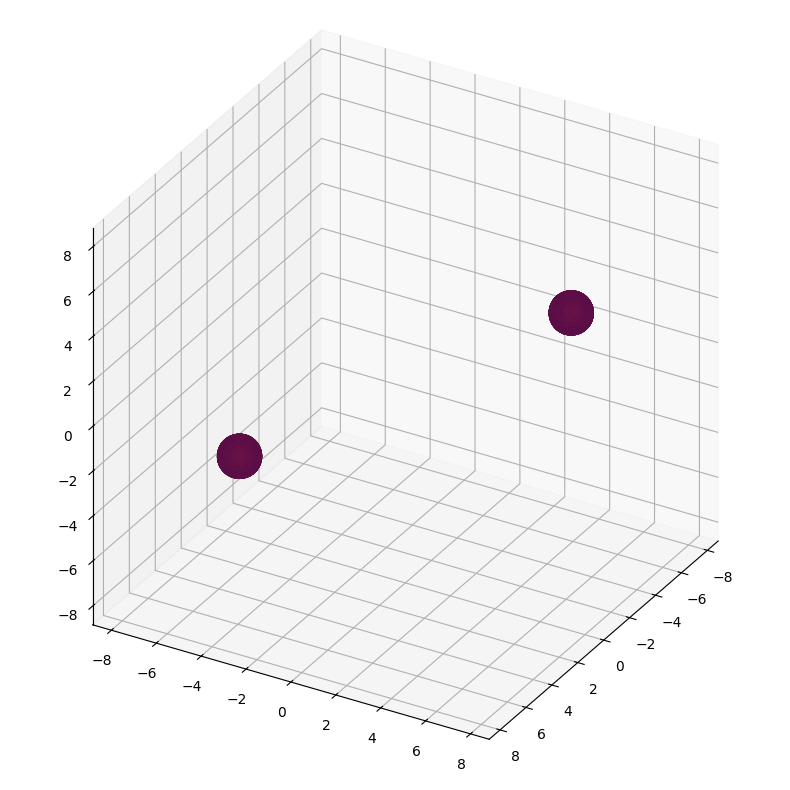

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

# Define start and end colors
start_color = mcolors.to_rgba('navy')  # 'tab:blue'
end_color = mcolors.to_rgba('firebrick')    # brown

# Create a custom colormap
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list('BlueToBrown', [start_color, end_color])

colorcycle=["#E69F00", "#56B4E9", "#009E73", "#0072B2", "#D55E00", "#CC79A7", "#F0E442"]
# Original positions
x, y, z = pos[:,0], pos[:,1], pos[:,2]

# Convert to spherical coordinates
r = np.sqrt(x**2 + y**2 + z**2)
theta = np.arccos(z / r)           # polar angle: 0 at north pole
phi = np.arctan2(y, x)             # azimuthal angle: -pi to pi
phi = np.mod(phi, 2*np.pi)         # convert to 0 - 2pi

# Mask out the octant: theta in [0, pi/2], phi in [0, pi/2]
octant_mask = r>0#~((theta >= 0) & (theta <= np.pi/2) & (phi >= 0) & (phi <= np.pi/2))

x_mask = x[octant_mask]
y_mask = y[octant_mask]
z_mask = z[octant_mask]
compid_mask = compid[octant_mask]
temp_mask = temp[octant_mask]

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Camera view parameters
elev, azim = 30, 30
ax.view_init(elev=elev, azim=azim)

# Scatter per component, sorted by distance along camera direction
alphas = np.zeros_like(x_mask)

for i, compi in enumerate(unique_comp):
    comp_indx = compid_mask == compi
    alphas[comp_indx] = 0.6-i*0.3


ax.scatter(x_mask, y_mask, z_mask, c=temp_mask, alpha=alphas, s=0.05, cmap=custom_cmap)

# Equal aspect ratio
max_range = np.array([x_mask.max()-x_mask.min(),
                      y_mask.max()-y_mask.min(),
                      z_mask.max()-z_mask.min()])
max_range_val = max(max_range)/2
mid_x = (x_mask.max()+x_mask.min())*0.5
mid_y = (y_mask.max()+y_mask.min())*0.5
mid_z = (z_mask.max()+z_mask.min())*0.5
ax.set_xlim(mid_x - max_range_val, mid_x + max_range_val)
ax.set_ylim(mid_y - max_range_val, mid_y + max_range_val)
ax.set_zlim(mid_z - max_range_val, mid_z + max_range_val)

ax.set_box_aspect([1,1,1])
ax.set_proj_type('ortho')   # optional but recommended
# ax.set_axis_off()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

# Define start and end colors
start_color = mcolors.to_rgba('navy')  # 'tab:blue'
end_color = mcolors.to_rgba('firebrick')    # brown

# Create a custom colormap
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list('BlueToBrown', [start_color, end_color])

snap_start = 0
snap_end   = 160

massratio = 0.5           #planet mass/Earth mass
datadir = f"data{massratio*100:.0f}"
plotdir = f"plot{massratio*100:.0f}"
# -------- loop snapshots --------
for i in range(snap_start, snap_end + 1):
    # fname = 'n85_gizmo.hdf5'
    fname = f"{datadir}/snapshot_{i:03d}.hdf5"
    outname = f"{plotdir}/sphere_{i:03d}.png"

    if not os.path.exists(fname):
        print(f"Missing {fname}, skip")
        continue
    if os.path.exists(outname):
        print(f"Existing {outname}, skip")
        continue
    with h5py.File(fname,'r') as f:
        pos = f['/PartType0/Coordinates'][()]   # code units
        m = f['/PartType0/Masses'][()]         # code units
        temp = f['/PartType0/Temperature'][()]
        compid = f['/PartType0/CompositionType'][()]
        time = f["Header"].attrs["Time"]
            
    x, y, z = pos[:,0], pos[:,1], pos[:,2]

    # Convert to spherical coordinates
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arccos(z / r)           # polar angle: 0 at north pole
    phi = np.arctan2(y, x)             # azimuthal angle: -pi to pi
    phi = np.mod(phi, 2*np.pi)         # convert to 0 - 2pi

    # Mask out the octant: theta in [0, pi/2], phi in [0, pi/2]
    octant_mask = ~((theta >= 0) & (theta <= np.pi/2) & (phi >= 0) & (phi <= np.pi/2))

    x_mask = x[octant_mask]
    y_mask = y[octant_mask]
    z_mask = z[octant_mask]
    compid_mask = compid[octant_mask]
    temp_mask = temp[octant_mask]

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')

    # Camera view parameters
    elev, azim = 30, 30
    ax.view_init(elev=elev, azim=azim)

    # Scatter per component, sorted by distance along camera direction
    alphas = np.zeros_like(x_mask)

    for i, compi in enumerate(unique_comp):
        comp_indx = compid_mask == compi
        alphas[comp_indx] = 0.6-i*0.3

    norm = Normalize(vmin = 500, vmax = 5000, clip = False)
    ax.scatter(x_mask, y_mask, z_mask, c=temp_mask, alpha=alphas, s=0.05, cmap=custom_cmap)

    # Equal aspect ratio
    max_range = np.array([x_mask.max()-x_mask.min(),
                        y_mask.max()-y_mask.min(),
                        z_mask.max()-z_mask.min()])
    max_range_val = max(max_range)/2
    mid_x = (x_mask.max()+x_mask.min())*0.5
    mid_y = (y_mask.max()+y_mask.min())*0.5
    mid_z = (z_mask.max()+z_mask.min())*0.5
    ax.set_xlim(mid_x - max_range_val, mid_x + max_range_val)
    ax.set_ylim(mid_y - max_range_val, mid_y + max_range_val)
    ax.set_zlim(mid_z - max_range_val, mid_z + max_range_val)

    ax.set_box_aspect([1,1,1])
    ax.set_proj_type('ortho')   # optional but recommended
    ax.set_axis_off()

    plt.tight_layout()
    plt.savefig(outname, dpi=200)
    plt.close()
    print(f"Saved {outname}")

Existing plot50/sphere_000.png, skip
Existing plot50/sphere_001.png, skip
Existing plot50/sphere_002.png, skip
Existing plot50/sphere_003.png, skip
Existing plot50/sphere_004.png, skip
Existing plot50/sphere_005.png, skip
Existing plot50/sphere_006.png, skip
Existing plot50/sphere_007.png, skip
Existing plot50/sphere_008.png, skip
Existing plot50/sphere_009.png, skip
Existing plot50/sphere_010.png, skip
Existing plot50/sphere_011.png, skip
Existing plot50/sphere_012.png, skip
Existing plot50/sphere_013.png, skip
Saved plot50/sphere_014.png
Saved plot50/sphere_015.png
Saved plot50/sphere_016.png
Saved plot50/sphere_017.png
Saved plot50/sphere_018.png
Saved plot50/sphere_019.png
Saved plot50/sphere_020.png
Saved plot50/sphere_021.png
Saved plot50/sphere_022.png
Saved plot50/sphere_023.png
Saved plot50/sphere_024.png
Saved plot50/sphere_025.png
Saved plot50/sphere_026.png
Saved plot50/sphere_027.png
Saved plot50/sphere_028.png
Saved plot50/sphere_029.png
Saved plot50/sphere_030.png
Saved 

KeyboardInterrupt: 

In [8]:
import subprocess as sp
sp.run(["rm", "sphere_relaxing"+".mp4" ])
cmd = [
    "ffmpeg",
    "-r", "10",
    "-i", plotdir+"/sphere_%03d.png",
    "-vcodec", "libx264",
    "-pix_fmt", "yuv420p",
    "sphere_relaxing"+".mp4"
]

sp.run(cmd, check=True)

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

CompletedProcess(args=['ffmpeg', '-r', '10', '-i', 'plot/sphere_%03d.png', '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', 'sphere_relaxing.mp4'], returncode=0)